In [1]:
print("ok")

ok


In [2]:
# ================================================================
# NANOORACLE BENJAMIN — CELLULE 1 : DATA PROCESSING
# ================================================================
# Entrées : train_benjamin.xlsx (102 formulations, séries 1+2)
#           test_3.xlsx         (52 formulations, série 3)
# Sorties : X_train, X_test, y_train, y_test
#           df_train, df_test, encoders, FEATURES, LIPID_SMILES, SEUILS
# Split   : fusion → déduplication → 80/20 aléatoire (seed=7)
# ================================================================

import pandas as pd
import numpy as np
import re, os, datetime
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

# ── Configuration ─────────────────────────────────────────────────
WORK_DIR    = r'C:\Pierre\D4Gen_2026'
OUT_DIR     = os.path.join(WORK_DIR, 'MVP_ben_dataset')
PREPROCESSING_DIR = os.path.join(OUT_DIR, 'preprocessing_cellule_1')
os.makedirs(PREPROCESSING_DIR, exist_ok=True)
RANDOM_SEED = 7      # validée sur 100 splits : Size MAE=2.76nm, 100% ≤ seuil
TEST_SIZE   = 0.20

PATH_TRAIN_BEN = os.path.join(WORK_DIR, 'NanoOracle_Dataset_v3_verified_cleaned_v2_train_benjamin.xlsx')
PATH_TEST3     = os.path.join(WORK_DIR, 'NanoOracle_Dataset_v3_verified_cleaned_v2_test_3.xlsx')
PATH_FUSED     = os.path.join(PREPROCESSING_DIR, 'NanoOracle_Dataset_benjamin_fused.xlsx')

# Seuils experts MAE acceptables
SEUILS = {
    'Size_nm': 5.0,   # nm
    'EE_pct':  5.0,   # %
    'PDI':     0.05,  # —
    'Zeta_mV': 2.0,   # mV
}

# ── Fonctions utilitaires ─────────────────────────────────────────
def fix_excel_datetime(val):
    """Excel parse parfois les mol% décimaux en dates. On récupère le .day."""
    if isinstance(val, (datetime.datetime, pd.Timestamp)):
        return float(val.day)
    try:    return float(val)
    except: return np.nan

def extract_pH(s):
    if pd.isna(s): return np.nan
    m = re.search(r'pH\s*([0-9]+[.,]?[0-9]*)', str(s), re.IGNORECASE)
    return float(m.group(1).replace(',', '.')) if m else np.nan

def extract_mM(s):
    if pd.isna(s): return np.nan
    m = re.search(r'(\d+)\s*mM', str(s), re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

def load_clean(path, source_label):
    """Charge un fichier Excel Benjamin et nettoie les bugs connus."""
    try:
        df = pd.read_excel(path, sheet_name='DATASET', header=1)
    except ValueError:
        df = pd.read_excel(path, header=0)
    df.columns = df.columns.str.strip()
    df = df[df['Lipid (ionizable/cationic)'] != 'categorical'].copy()
    df = df[df['Lipid (ionizable/cationic)'].notna()].copy()
    df = df.reset_index(drop=True)
    # Fix datetime sur colonnes mol%
    for col in ['Helper mol%', 'PEG-Lipid mol%']:
        if col in df.columns:
            df[col] = df[col].apply(fix_excel_datetime)
    # Technique_Enc manquant dans test_3 → forcer microfluidic
    if 'Technique_Enc' not in df.columns or df['Technique_Enc'].isna().all():
        df['Technique_Enc'] = 'microfluidic'
    df['source'] = source_label
    return df

# ── 1. Chargement ─────────────────────────────────────────────────
print('═' * 60)
print('  CELLULE 1 — DATA PROCESSING')
print('═' * 60)
print('\n── Chargement ──')

df_train_ben = load_clean(PATH_TRAIN_BEN, 'serie_train')
df_test3     = load_clean(PATH_TEST3,     'serie_test3')

size_tr = pd.to_numeric(df_train_ben['Size (Z-avg)'], errors='coerce').mean()
size_t3 = pd.to_numeric(df_test3['Size (Z-avg)'], errors='coerce').mean()

print(f'  train_benjamin : {len(df_train_ben)} formulations  '
      f'(Size mean={size_tr:.1f}nm, FRR={sorted(pd.to_numeric(df_train_ben["FRR (aq:org)"], errors="coerce").dropna().unique().tolist())})')
print(f'  test_3         : {len(df_test3)} formulations  '
      f'(Size mean={size_t3:.1f}nm, FRR={sorted(pd.to_numeric(df_test3["FRR (aq:org)"], errors="coerce").dropna().unique().tolist())})')

# ── 2. Fusion + déduplication ──────────────────────────────────────
print('\n── Fusion + déduplication ──')

KEY_COLS = ['Lipid (ionizable/cationic)', 'Ionizable mol%',
            'FRR (aq:org)', 'Size (Z-avg)', 'EE%']

df_all = pd.concat([df_train_ben, df_test3], ignore_index=True)
dupes  = df_all.duplicated(subset=KEY_COLS, keep='first')
print(f'  Doublons détectés et supprimés : {dupes.sum()}')
df_all = df_all[~dupes].reset_index(drop=True)
df_all['ID'] = range(1, len(df_all) + 1)

print(f'  Total après fusion : {len(df_all)} formulations')
print(f'  Lipides  : {df_all["Lipid (ionizable/cationic)"].value_counts().to_dict()}')
print(f'  Sources  : {df_all["source"].value_counts().to_dict()}')
print(f'  FRR      : {sorted(pd.to_numeric(df_all["FRR (aq:org)"], errors="coerce").dropna().unique().tolist())}')

# Sauvegarde du dataset fusionné
df_all.to_excel(PATH_FUSED, index=False)
print(f'  Sauvegardé → NanoOracle_Dataset_benjamin_fused.xlsx')

# ── 3. Preprocessing numérique ────────────────────────────────────
print('\n── Preprocessing numérique ──')

num_map = {
    'Ionizable_pct': 'Ionizable mol%',
    'Helper_pct':    'Helper mol%',
    'Chol_pct':      'Cholesterol mol%',
    'PEG_pct':       'PEG-Lipid mol%',
    'NP_ratio':      'N/P Ratio',
    'FRR':           'FRR (aq:org)',
    'TFR':           'Total Flow Rate',
    'Size_nm':       'Size (Z-avg)',
    'PDI':           'PDI',
    'Zeta_mV':       'Zeta Potential',
    'EE_pct':        'EE%',
}
for new, old in num_map.items():
    df_all[new] = pd.to_numeric(df_all.get(old, np.nan), errors='coerce')

# Buffer pH et mM — colonne dédiée prioritaire, regex en fallback
if 'pH Buffer' in df_all.columns:
    df_all['Buffer_pH'] = pd.to_numeric(df_all['pH Buffer'], errors='coerce')
elif 'Aqueous Buffer' in df_all.columns:
    df_all['Buffer_pH'] = df_all['Aqueous Buffer'].apply(extract_pH)
else:
    df_all['Buffer_pH'] = np.nan

if 'mM Buffer' in df_all.columns:
    df_all['Buffer_mM'] = pd.to_numeric(df_all['mM Buffer'], errors='coerce')
elif 'Aqueous Buffer' in df_all.columns:
    df_all['Buffer_mM'] = df_all['Aqueous Buffer'].apply(extract_mM)
else:
    df_all['Buffer_mM'] = np.nan

# Technique
df_all['technique_enc'] = df_all['Technique_Enc'].map(
    {'microfluidic': 1, 'pipette_mixing': 0}).fillna(1).astype(int)
print(f'  technique_enc=1 : {df_all["technique_enc"].sum()}/{len(df_all)} microfluidique')

# ── 4. Encodage catégoriel ────────────────────────────────────────
print('\n── Encodage catégoriel ──')
CAT_COLS = ['Lipid (ionizable/cationic)', 'Helper Lipid', 'PEG-Lipid', 'Cargo Type']
encoders = {}
for col in CAT_COLS:
    df_all[col] = df_all[col].fillna('Unknown').astype(str).str.strip()
    le = LabelEncoder()
    df_all[col + '_enc'] = le.fit_transform(df_all[col])
    encoders[col] = le
    print(f'  {col:<35} : {df_all[col].nunique()} catégories '
          f'→ {list(le.classes_)}')

# ── 5. Descripteurs RDKit ─────────────────────────────────────────
print('\n── Descripteurs RDKit ──')
LIPID_SMILES = {
    'MC3':          r'CCCCCCCC/C=C\CCCCCCCC(=O)OCC(COC(=O)CCCCCCC/C=C\CCCCCCCC)N(CC)CC',
    'SM-102':       r'CCCCCCCC/C=C\CCCCCCCC(=O)OCC(COC(=O)CCCCCCC/C=C\CCCCCCCC)N(CCOCCO)CCOCCO',
    'ALC-0315':     r'CCCCCCCC/C=C\CCCCCCCC(=O)OCC(COC(=O)CCCCCCC/C=C\CCCCCCCC)N1CCCCC1',
    'DOTAP':        'CCCCCCCCCCCCCCCC(=O)OCC(COC(=O)CCCCCCCCCCCCCCC)[N+](C)(C)CC',
    'DODAP':        'CCCCCCCCCCCCCCCC(=O)OCC(COC(=O)CCCCCCCCCCCCCCC)N(CC)CC',
    'DDAB':         'CCCCCCCCCCCCCCCC[N+](C)(C)CCCCCCCCCCCCCCCC',
    'DLin-MC3-DMA': r'CCCCCCCC/C=C\CCCCCCC(=O)OCC(COC(=O)CCCCCCC/C=C\CCCCCCCC)N(CC)CC',
    'DLin-KC2-DMA': r'CCCCCCCC/C=C\CCCCCCCC(CCN(CC)CC)OC(=O)CCCCCCC/C=C\CCCCCCCC',
    'C12-200':      'CCCCCCCCCCCCN(CCCCCCCCCCCC)CCN(CCCCCCCCCCCC)CCCCCCCCCCCC',
    'C14-4':        'CCCCCCCCCCCCCCN(CCCCCCCCCCCCCC)CCN(CCCCCCCCCCCCCC)CCCCCCCCCCCCCC',
    'TCL053': None, 'TCL065': None, 'TRENL3': None,
    'CL15H6': None, 'CL15A6': None,
}

RDKIT_COLS = ['MolWt', 'LogP', 'TPSA', 'NumHDonors',
              'NumHAcceptors', 'NumRotBonds', 'FractionCSP3', 'NumAmines']

def smiles_to_descriptors(name):
    smi = LIPID_SMILES.get(str(name).strip())
    if smi is None: return [np.nan] * 8
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None: return [np.nan] * 8
        return [
            Descriptors.MolWt(mol),      Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),        rdMolDescriptors.CalcNumHBD(mol),
            rdMolDescriptors.CalcNumHBA(mol),
            rdMolDescriptors.CalcNumRotatableBonds(mol),
            rdMolDescriptors.CalcFractionCSP3(mol),
            sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 7),
        ]
    except: return [np.nan] * 8

tqdm.pandas(desc='  RDKit')
desc = df_all['Lipid (ionizable/cationic)'].progress_apply(smiles_to_descriptors)
df_all[RDKIT_COLS] = pd.DataFrame(desc.tolist(), index=df_all.index)
n_smiles = df_all['MolWt'].notna().sum()
print(f'  SMILES résolus : {n_smiles}/{len(df_all)} ({n_smiles/len(df_all)*100:.0f}%)')

# ── 6. Features d'interaction molaire ────────────────────────────
df_all['IL_Chol_ratio']   = df_all['Ionizable_pct'] / (df_all['Chol_pct']   + 1e-6)
df_all['IL_Helper_ratio'] = df_all['Ionizable_pct'] / (df_all['Helper_pct'] + 1e-6)
df_all['PEG_total_ratio'] = df_all['PEG_pct'] / (
    df_all['Ionizable_pct'] + df_all['Helper_pct'] +
    df_all['Chol_pct']      + df_all['PEG_pct'] + 1e-6)

# ── 7. Features finales ───────────────────────────────────────────
FEATURES = [
    'Ionizable_pct', 'Helper_pct', 'Chol_pct', 'PEG_pct',
    'NP_ratio', 'FRR', 'TFR', 'Buffer_pH', 'Buffer_mM',
    'IL_Chol_ratio', 'IL_Helper_ratio', 'PEG_total_ratio',
    'Lipid (ionizable/cationic)_enc',
    'Helper Lipid_enc', 'PEG-Lipid_enc', 'Cargo Type_enc',
    'technique_enc',
] + RDKIT_COLS

for f in FEATURES:
    df_all[f] = pd.to_numeric(df_all[f], errors='coerce')

X_all = df_all[FEATURES].copy()

# ── 8. Split 80/20 ────────────────────────────────────────────────
print(f'\n── Split 80/20 (seed={RANDOM_SEED}) ──')
train_idx, test_idx = train_test_split(
    df_all.index, test_size=TEST_SIZE,
    random_state=RANDOM_SEED, shuffle=True)

df_train = df_all.loc[train_idx].reset_index(drop=True)
df_test  = df_all.loc[test_idx].reset_index(drop=True)
X_train  = X_all.loc[train_idx].reset_index(drop=True)
X_test   = X_all.loc[test_idx].reset_index(drop=True)

TARGETS_COLS = {
    'Size_nm': 'nm', 'EE_pct': '%', 'PDI': '', 'Zeta_mV': 'mV'
}
y_train, y_test = {}, {}
for name in TARGETS_COLS:
    y_train[name] = df_train[name].copy()
    y_test[name]  = df_test[name].copy()

# ── 9. Résumé ─────────────────────────────────────────────────────
print(f'\n  {"":20} {"Train (N=" + str(len(df_train)) + ")":>16}  '
      f'{"Test (N=" + str(len(df_test)) + ")":>16}')
print(f'  {"-"*55}')

# Distribution par source
for src in sorted(df_all['source'].unique()):
    n_tr = (df_train['source'] == src).sum()
    n_te = (df_test['source']  == src).sum()
    print(f'  {src:<20} {n_tr:>16}  {n_te:>16}')

# Distribution par lipide
print(f'  {"-"*55}')
for lipid in ['MC3', 'SM-102']:
    n_tr = (df_train['Lipid (ionizable/cationic)'] == lipid).sum()
    n_te = (df_test['Lipid (ionizable/cationic)']  == lipid).sum()
    print(f'  {lipid:<20} {n_tr:>16}  {n_te:>16}')

# Outputs
print(f'\n  {"Output":<12} {"N_train":>8} {"mean_train":>11}  '
      f'{"N_test":>7} {"mean_test":>10}')
print(f'  {"-"*52}')
for name, unit in TARGETS_COLS.items():
    tr_vals = y_train[name].dropna()
    te_vals = y_test[name].dropna()
    print(f'  {name:<12} {len(tr_vals):>8} {tr_vals.mean():>10.2f}{unit}  '
          f'{len(te_vals):>7} {te_vals.mean():>9.2f}{unit}')

# Remplissage features
print(f'\n── Remplissage features (train) ──')
for f in FEATURES:
    pct = float(X_train[f].notna().sum()) / len(X_train) * 100
    bar = '█' * int(pct / 5)
    print(f'  {f:<35} {pct:>5.0f}% {bar}')

print('\n' + '═' * 60)
print('  ✅ Cellule 1 terminée')
print('  Variables disponibles pour Cellule 2 :')
print('    X_train, X_test, y_train, y_test')
print('    df_train, df_test, FEATURES, SEUILS')
print('    encoders, LIPID_SMILES')
print('═' * 60)

════════════════════════════════════════════════════════════
  CELLULE 1 — DATA PROCESSING
════════════════════════════════════════════════════════════

── Chargement ──
  train_benjamin : 102 formulations  (Size mean=81.8nm, FRR=[3, 5, 6, 8])
  test_3         : 52 formulations  (Size mean=70.7nm, FRR=[3, 6, 8])

── Fusion + déduplication ──
  Doublons détectés et supprimés : 1
  Total après fusion : 153 formulations
  Lipides  : {'MC3': 109, 'SM-102': 44}
  Sources  : {'serie_train': 102, 'serie_test3': 51}
  FRR      : [3, 5, 6, 8]
  Sauvegardé → NanoOracle_Dataset_benjamin_fused.xlsx

── Preprocessing numérique ──
  technique_enc=1 : 153/153 microfluidique

── Encodage catégoriel ──
  Lipid (ionizable/cationic)          : 2 catégories → ['MC3', 'SM-102']
  Helper Lipid                        : 1 catégories → ['DSPC']
  PEG-Lipid                           : 1 catégories → ['DMG-PEG']
  Cargo Type                          : 1 catégories → ['siRNA']

── Descripteurs RDKit ──


  RDKit: 100%|██████████| 153/153 [00:00<00:00, 502.73it/s]

  SMILES résolus : 153/153 (100%)

── Split 80/20 (seed=7) ──

                          Train (N=122)       Test (N=31)
  -------------------------------------------------------
  serie_test3                        38                13
  serie_train                        84                18
  -------------------------------------------------------
  MC3                                87                22
  SM-102                             35                 9

  Output        N_train  mean_train   N_test  mean_test
  ----------------------------------------------------
  Size_nm           121      79.19nm       31     74.11nm
  EE_pct            122      83.28%       31     82.86%
  PDI               122       0.13       31      0.13
  Zeta_mV           112       0.05mV       30     -0.11mV

── Remplissage features (train) ──
  Ionizable_pct                         100% ████████████████████
  Helper_pct                            100% ████████████████████
  Chol_pct               

════════════════════════════════════════════════════════════
  CELLULE 2 — ENTRAÎNEMENT (train uniquement, N= 122 )
════════════════════════════════════════════════════════════

  XGBoost — KFold 5-fold (shuffle, seed=42)
  Le jeu de test (31 formulations) n'est PAS utilisé ici.

── Size_nm (N_train=121) ──
  R² CV    : 0.589 ± 0.127
  MAE CV   : 6.417nm ± 0.608nm
  MAE OOF  : 6.417nm   RMSE OOF : 8.292nm
  Biais OOF: -0.039nm  MAE/std : 0.47
  Seuil 5.0nm : ⚠️

  Sauvegardé → nanooracle_benjamin_Size_nm.pkl
── EE_pct (N_train=122) ──
  R² CV    : 0.150 ± 0.220
  MAE CV   : 4.968% ± 0.682%
  MAE OOF  : 4.961%   RMSE OOF : 6.229%
  Biais OOF: -0.131%  MAE/std : 0.71
  Seuil 5.0% : ✅

  Sauvegardé → nanooracle_benjamin_EEpct.pkl
── PDI (N_train=122) ──
  R² CV    : 0.025 ± 0.238
  MAE CV   : 0.039 ± 0.005
  MAE OOF  : 0.039   RMSE OOF : 0.048
  Biais OOF: -0.001  MAE/std : 0.78
  Seuil 0.05 : ✅

  Sauvegardé → nanooracle_benjamin_PDI.pkl
── Zeta_mV (N_train=112) ──
  R² CV    : -0.238 ± 

KeyError: 'r2_test'

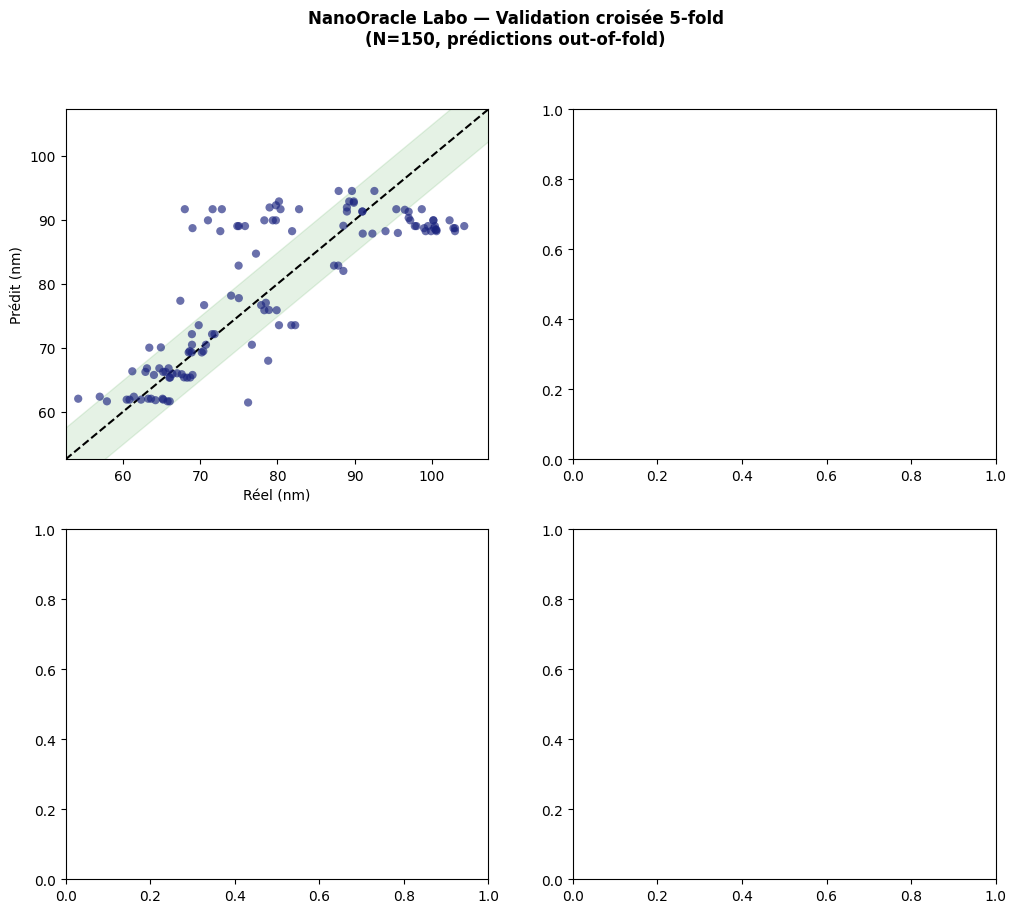

In [ ]:
# ================================================================
# NANOORACLE BENJAMIN — CELLULE 2 : ENTRAÎNEMENT
# ================================================================
# Entrée  : X_train, y_train, FEATURES, SEUILS (Cellule 1)
# Méthode : XGBoost + KFold 5-fold sur train UNIQUEMENT
# Sorties : 4 modèles .pkl, métriques CV, 3 figures
# ================================================================

import pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error

# ── Hyperparamètres ────────────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators     = 500,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.6,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

TRAIN_OUT_DIR= os.path.join(OUT_DIR, 'train_cellule_2')
os.makedirs(TRAIN_OUT_DIR, exist_ok=True)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

UNITS  = {'Size_nm': 'nm', 'EE_pct': '%', 'PDI': '', 'Zeta_mV': 'mV'}
COLORS = {'Size_nm': '#1a237e', 'EE_pct': '#00695c',
          'PDI': '#6a1b9a', 'Zeta_mV': '#b71c1c'}
PKL_NAMES = {
    'Size_nm': 'nanooracle_benjamin_Size_nm.pkl',
    'EE_pct':  'nanooracle_benjamin_EEpct.pkl',
    'PDI':     'nanooracle_benjamin_PDI.pkl',
    'Zeta_mV': 'nanooracle_benjamin_Zeta_mV.pkl',
}

models  = {}
results = {}

print('═' * 60)
print('  CELLULE 2 — ENTRAÎNEMENT (train uniquement, N=', len(X_train), ')')
print('═' * 60)
print(f'\n  XGBoost — KFold 5-fold (shuffle, seed=42)')
print(f'  Le jeu de test ({len(X_test)} formulations) n\'est PAS utilisé ici.\n')

# ================================================================
# BOUCLE D'ENTRAÎNEMENT
# ================================================================
for name in UNITS:
    unit  = UNITS[name]
    color = COLORS[name]
    y_tr  = y_train[name]

    mask = y_tr.notna().values
    Xm   = X_train[mask].copy()
    ym   = y_tr[mask].copy()
    n    = mask.sum()

    print(f'── {name} (N_train={n}) ──')

    model = XGBRegressor(**XGB_PARAMS)

    # Cross-validation scores
    cv_r2  = cross_val_score(model, Xm, ym, cv=cv, scoring='r2')
    cv_mae = -cross_val_score(model, Xm, ym, cv=cv,
                               scoring='neg_mean_absolute_error')

    # Prédictions out-of-fold (jamais vu = honnête)
    y_oof = cross_val_predict(model, Xm, ym, cv=cv)

    r2_oof   = r2_score(ym, y_oof)
    mae_oof  = mean_absolute_error(ym, y_oof)
    bias_oof = float(np.mean(y_oof - ym.values))
    rmse_oof = float(np.sqrt(np.mean((y_oof - ym.values)**2)))
    std_y    = float(ym.std())
    mae_norm = mae_oof / std_y if std_y > 0 else np.nan

    seuil = SEUILS[name]
    flag  = '✅' if cv_mae.mean() <= seuil else \
            '⚠️' if cv_mae.mean() <= seuil * 2 else '❌'

    print(f'  R² CV    : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}')
    print(f'  MAE CV   : {cv_mae.mean():.3f}{unit} ± {cv_mae.std():.3f}{unit}')
    print(f'  MAE OOF  : {mae_oof:.3f}{unit}   RMSE OOF : {rmse_oof:.3f}{unit}')
    print(f'  Biais OOF: {bias_oof:+.3f}{unit}  MAE/std : {mae_norm:.2f}')
    print(f'  Seuil {seuil}{unit} : {flag}\n')

    # Fit final sur tout le train
    model.fit(Xm, ym)
    models[name] = model
    results[name] = {
        'r2_cv': cv_r2.mean(), 'r2_std': cv_r2.std(),
        'mae_cv': cv_mae.mean(), 'mae_std': cv_mae.std(),
        'r2_oof': r2_oof, 'mae_oof': mae_oof,
        'rmse_oof': rmse_oof, 'bias_oof': bias_oof,
        'mae_norm': mae_norm, 'std_y': std_y, 'n': n,
        'y_oof': y_oof, 'ym': ym,
        'flag': flag,
    }

    # Sauvegarde pkl (mae_cv embarquée pour Cellule 3)
    pkl_path = os.path.join(WORK_DIR, PKL_NAMES[name])
    with open(pkl_path, 'wb') as f:
        pickle.dump({
            'model':        model,
            'features':     FEATURES,
            'encoders':     encoders,
            'lipid_smiles': LIPID_SMILES,
            'mae_cv':       cv_mae.mean(),
            'r2_cv':        cv_r2.mean(),
            'seuil':        seuil,
        }, f)
    print(f'  Sauvegardé → {PKL_NAMES[name]}')

# ================================================================
# FIGURE 1 — Scatter pred vs réel (OOF)
# ================================================================
fig1, axes1 = plt.subplots(2, 2, figsize=(12, 10))
axes1 = axes1.flatten()
fig1.suptitle(
    f'NanoOracle Labo — Validation croisée 5-fold\n'
    f'(N={150}, prédictions out-of-fold)',
    fontsize=12, fontweight='bold')

for ax, name in zip(axes1, UNITS):
    r     = results[name]
    unit  = UNITS[name]
    color = COLORS[name]
    ym    = r['ym']
    y_oof = r['y_oof']

    ax.scatter(ym, y_oof, alpha=0.65, s=35,
               color=color, edgecolors='none', zorder=3)

    lims = [min(float(ym.min()), float(y_oof.min())) - abs(float(ym.min())) * 0.03,
            max(float(ym.max()), float(y_oof.max())) + abs(float(ym.max())) * 0.03]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Idéal', zorder=2)

    seuil = SEUILS[name]
    ax.fill_between(lims,
                    [l - seuil for l in lims],
                    [l + seuil for l in lims],
                    alpha=0.10, color='green',
                    label=f'±seuil ({seuil}{unit})', zorder=1)

    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'Réel ({unit})', fontsize=10)
    ax.set_ylabel(f'Prédit ({unit})', fontsize=10)
    status_txt = {'✅': '[OK]', '⚠️': '[~]', '❌': '[X]'}
    ax.set_title(
        f'{name}  {status_txt.get(r["flag"], r["flag"])}\n'
        f'R²={r["r2_oof"]:.3f}  '
        f'MAE={r["mae_oof"]:.3f}{unit}  '
        f'Biais={r["bias_oof"]:+.3f}{unit}',
        fontsize=9)
    ax.legend(fontsize=8)
    ax.set_aspect('equal', 'box')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig1_path = os.path.join(TRAIN_OUT_DIR, 'nanooracle_benjamin_cv_scatter.png')
plt.savefig(fig1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n  Figure 1 → nanooracle_benjamin_cv_scatter.png')

# ================================================================
# FIGURE 2 — Feature Importance (top 10)
# ================================================================
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 12))
axes2 = axes2.flatten()
fig2.suptitle('NanoOracle Labo — Feature Importances (XGBoost gain)',
              fontsize=12, fontweight='bold')

for ax, name in zip(axes2, UNITS):
    model = models[name]
    imp   = pd.Series(model.feature_importances_,
                      index=FEATURES).sort_values(ascending=True).tail(10)
    colors_bars = [COLORS[name] if v >= imp.quantile(0.6) else
                   COLORS[name] + '80' for v in imp.values]
    imp.plot(kind='barh', ax=ax, color=COLORS[name], alpha=0.82, edgecolor='none')
    ax.set_title(f'{name} — Top 10 features', fontsize=10)
    ax.set_xlabel('Importance (gain)', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
fig2_path = os.path.join(TRAIN_OUT_DIR, 'nanooracle_benjamin_importance.png')
plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Figure 2 → nanooracle_benjamin_importance.png')

# ================================================================
# FIGURE 3 — Analyse des résidus (OOF)
# ================================================================
fig3, axes3 = plt.subplots(2, 2, figsize=(12, 10))
axes3 = axes3.flatten()
fig3.suptitle('NanoOracle Labo — Résidus (prédit − réel)',
              fontsize=12, fontweight='bold')

for ax, name in zip(axes3, UNITS):
    r     = results[name]
    unit  = UNITS[name]
    color = COLORS[name]
    ym    = r['ym'].values
    y_oof = r['y_oof']
    resid = y_oof - ym
    seuil = SEUILS[name]

    ax.scatter(ym, resid, alpha=0.65, s=35,
               color=color, edgecolors='none', zorder=3)
    ax.axhline(0,       color='black',  lw=1.5, linestyle='--', zorder=2)
    ax.axhline( seuil,  color='#e53935', lw=1.2, linestyle=':',
                label=f'+seuil={seuil}{unit}', zorder=2)
    ax.axhline(-seuil,  color='#e53935', lw=1.2, linestyle=':',
                label=f'−seuil={seuil}{unit}', zorder=2)
    ax.fill_between(ax.get_xlim() if ax.get_xlim() != (0, 1) else
                    [float(ym.min()) - 1, float(ym.max()) + 1],
                    -seuil, seuil, alpha=0.07, color='green', zorder=1)

    pct_in = float((np.abs(resid) <= seuil).mean() * 100)
    ax.set_xlabel(f'Réel ({unit})', fontsize=10)
    ax.set_ylabel(f'Résidu prédit−réel ({unit})', fontsize=10)
    ax.set_title(
        f'{name} — {pct_in:.0f}% résidus dans ±seuil\n'
        f'Biais={r["bias_oof"]:+.3f}{unit}  RMSE={r["rmse_oof"]:.3f}{unit}',
        fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig3_path = os.path.join(TRAIN_OUT_DIR, 'nanooracle_benjamin_residus.png')
plt.savefig(fig3_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Figure 3 → nanooracle_benjamin_residus.png')

# ================================================================
# BILAN FINAL
# ================================================================
print('\n' + '═' * 68)
print('  NanoOracle Labo — Performances CV')
print('═' * 68)
print(f'  {"Target":<10} {"N":>4}  {"R² CV":>12}  {"MAE CV":>12}  '
      f'{"Biais":>9}  {"MAE/std":>8}  Statut')
print(f'  {"-"*65}')
for name, r in results.items():
    unit = UNITS[name]
    print(f'  {name:<10} {r["n"]:>4}  '
          f'{r["r2_cv"]:>6.3f}±{r["r2_std"]:.3f}  '
          f'{r["mae_cv"]:>6.3f}±{r["mae_std"]:.3f}{unit}  '
          f'{r["bias_oof"]:>+8.3f}{unit}  '
          f'{r["mae_norm"]:>8.2f}  {r["flag"]}')
print(f'  {"-"*65}')
print(f'  Seuils : Size≤5nm  EE≤5%  PDI≤0.05  Zeta≤2mV')
print(f'  MAE/std < 0.5 excellent | 0.5–1.0 acceptable | >1.0 insuffisant')
print('═' * 68)
print(f'\n  Modèles sauvegardés :')
for name, pkl in PKL_NAMES.items():
    print(f'    {pkl}')
print(f'\n  ✅ Cellule 2 terminée')
print(f'     Le jeu de test ({len(X_test)} formulations) n\'a PAS été vu.')
print(f'     → Lancer Cellule 3 pour l\'inférence.')

════════════════════════════════════════════════════════════
  CELLULE 3 — INFÉRENCE SUR JEU DE TEST
════════════════════════════════════════════════════════════

── Chargement des modèles ──
  Size_nm    ← nanooracle_benjamin_Size_nm.pkl
             MAE_CV=6.417nm  R²_CV=0.589  Seuil=5.0nm
  EE_pct     ← nanooracle_benjamin_EEpct.pkl
             MAE_CV=4.968%  R²_CV=0.150  Seuil=5.0%
  PDI        ← nanooracle_benjamin_PDI.pkl
             MAE_CV=0.039  R²_CV=0.025  Seuil=0.05
  Zeta_mV    ← nanooracle_benjamin_Zeta_mV.pkl
             MAE_CV=1.786mV  R²_CV=-0.238  Seuil=2.0mV

── Inférence sur 31 formulations de test ──
  Size_nm    prédit ✓
  EE_pct     prédit ✓
  PDI        prédit ✓
  Zeta_mV    prédit ✓

── Prédictions (10 premières lignes) ──
Lipid (ionizable/cationic) FRR (aq:org)      source  Size_nm_pred  EE_pct_pred  PDI_pred  Zeta_mV_pred
                       MC3            8 serie_train     61.830002    77.558998     0.121         0.117
                       MC3        

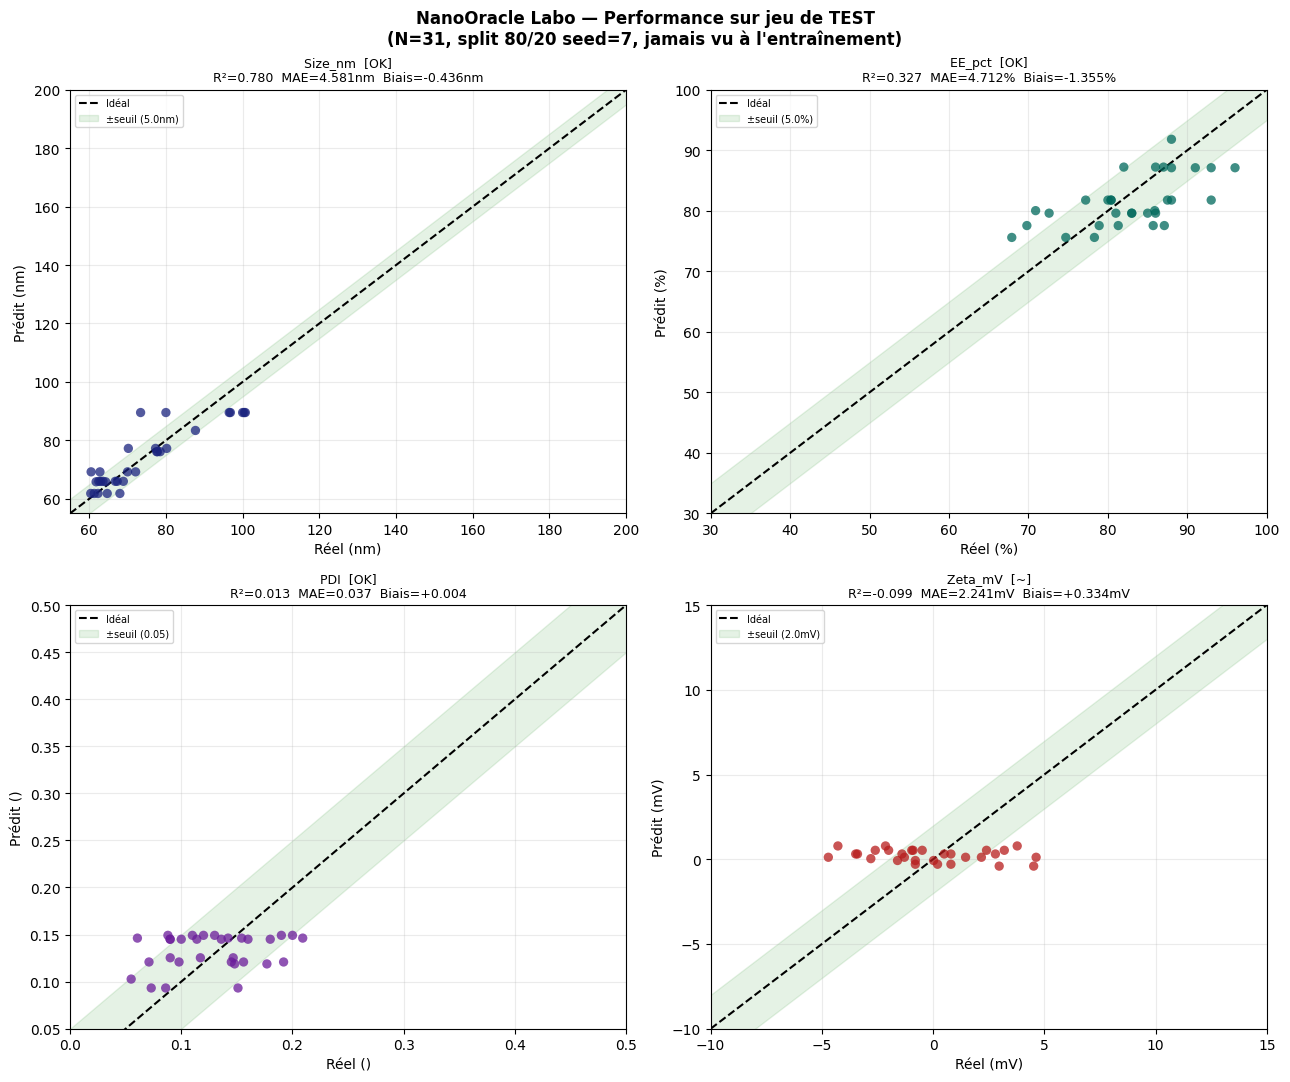


  Figure 1 → nanooracle_benjamin_test_scatter.png


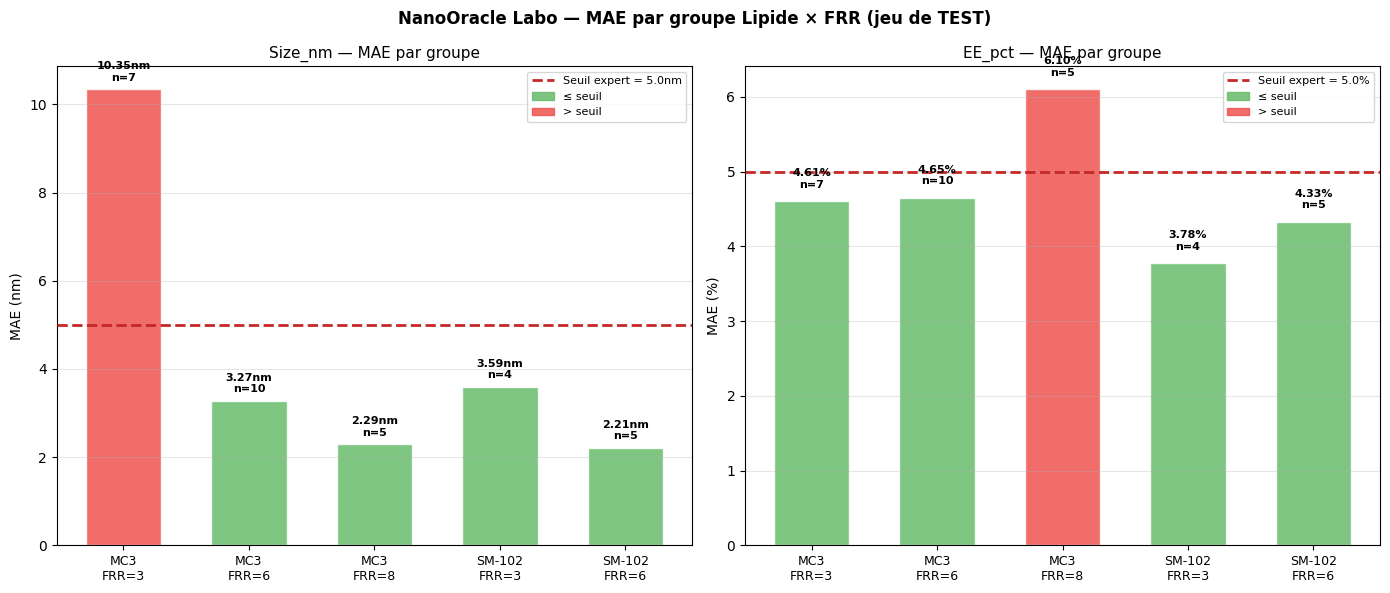

  Figure 2 → nanooracle_benjamin_test_groupes.png


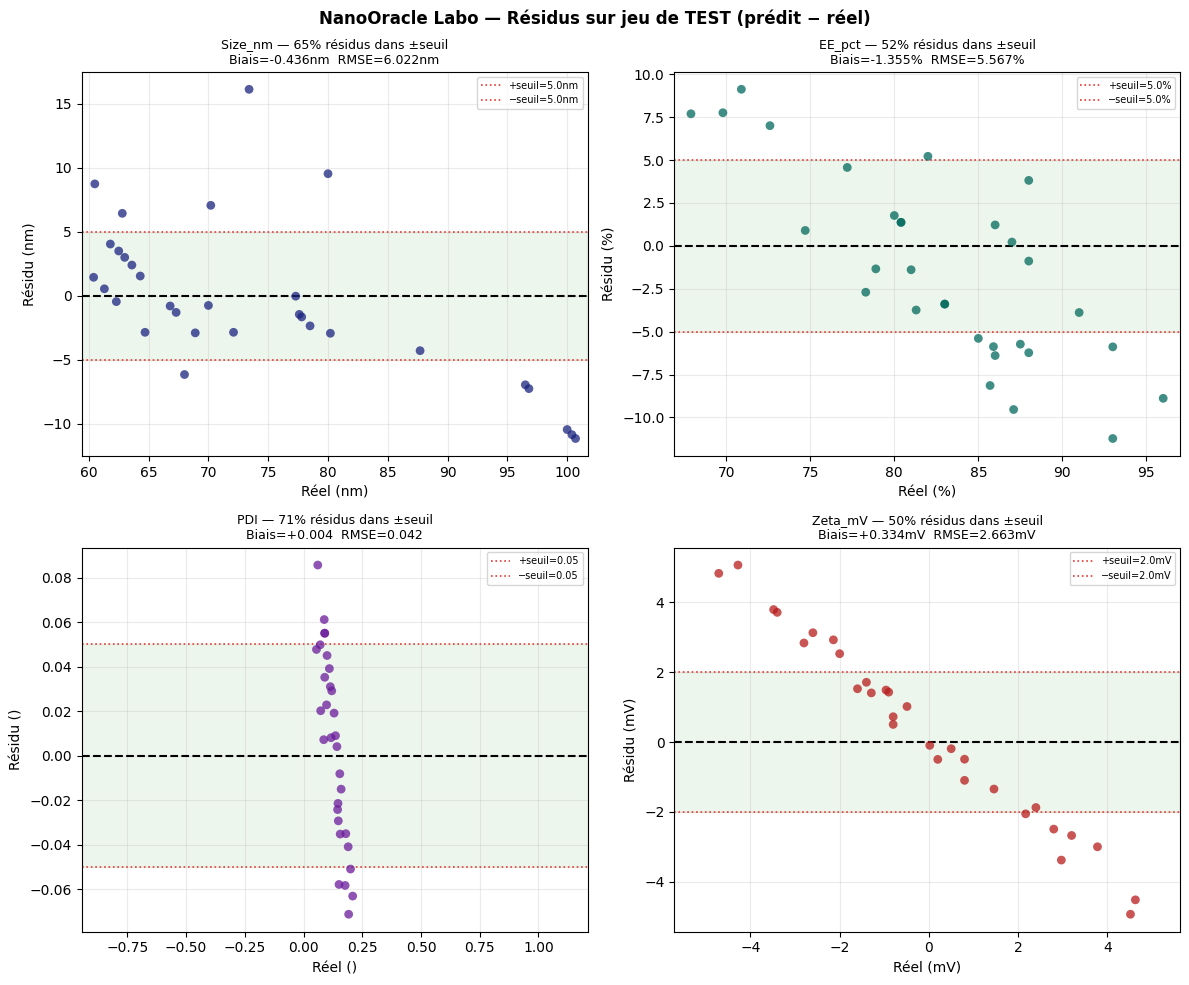

  Figure 3 → nanooracle_benjamin_test_residus.png


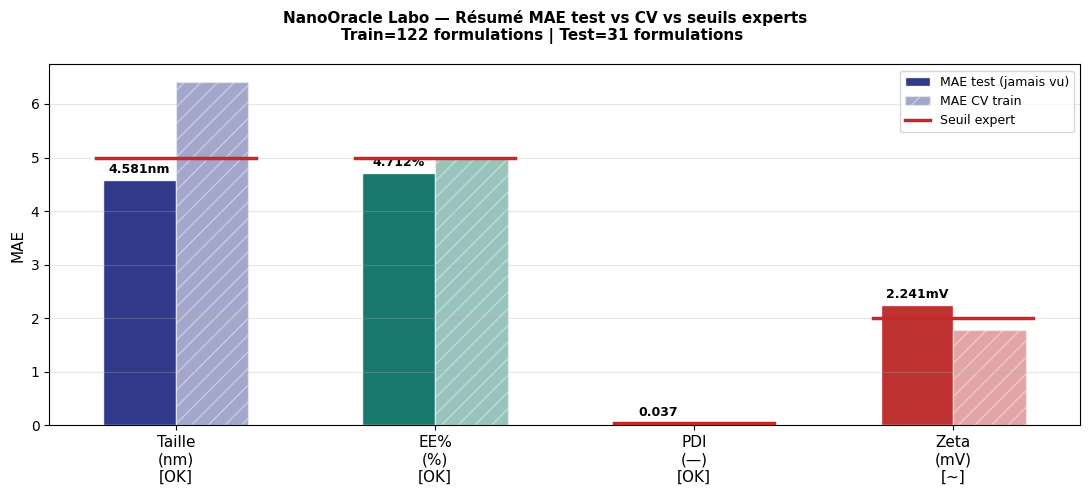

  Figure 4 → nanooracle_benjamin_dashboard.png

  Prédictions → nanooracle_benjamin_predictions_test.xlsx

════════════════════════════════════════════════════════════════════
  NanoOracle Benjamin — Performance FINALE sur jeu de TEST
════════════════════════════════════════════════════════════════════
  Target        N    MAE_test      MAE_CV      Biais   MAE/std  Statut
  ---------------------------------------------------------------
  Size_nm      31      4.581nm      6.417nm    -0.436nm      0.36  ✅
  EE_pct       31      4.712%      4.968%    -1.355%      0.69  ✅
  PDI          31      0.037      0.039    +0.004      0.87  ✅
  Zeta_mV      30      2.241mV      1.786mV    +0.334mV      0.88  ⚠️
  ---------------------------------------------------------------
  Split  : 122 train / 31 test (80/20, seed=7)
  Seuils : Size≤5nm  EE≤5%  PDI≤0.05  Zeta≤2mV
  Figures sauvegardées :
    nanooracle_benjamin_test_scatter.png
    nanooracle_benjamin_test_groupes.png
    nanooracle_benjamin_

In [27]:
# ================================================================
# NANOORACLE BENJAMIN — CELLULE 3 : INFÉRENCE SUR JEU DE TEST
# ================================================================
# Entrée  : X_test, y_test, df_test (Cellule 1)
#           4 modèles .pkl (Cellule 2)
# Sorties : prédictions, métriques test, 4 figures, Excel résultats
# ================================================================

import pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.metrics import r2_score, mean_absolute_error

OUT_TEST_DIR = os.path.join(OUT_DIR, 'test_cellule_3')
os.makedirs(OUT_TEST_DIR, exist_ok=True)

UNITS  = {'Size_nm': 'nm', 'EE_pct': '%', 'PDI': '', 'Zeta_mV': 'mV'}
COLORS = {'Size_nm': '#1a237e', 'EE_pct': '#00695c',
          'PDI': '#6a1b9a', 'Zeta_mV': '#b71c1c'}
PKL_NAMES = {
    'Size_nm': 'nanooracle_benjamin_Size_nm.pkl',
    'EE_pct':  'nanooracle_benjamin_EEpct.pkl',
    'PDI':     'nanooracle_benjamin_PDI.pkl',
    'Zeta_mV': 'nanooracle_benjamin_Zeta_mV.pkl',
}

# Ranges fixes par target
FIXED_LIMS = {
    'Size_nm':  ([55, 200],  [55, 200]),
    'EE_pct':   ([30, 100],  [30, 100]),
    'PDI':      ([0.0, 0.5], [0.05, 0.50]),
    'Zeta_mV':  ([-10, 15],  [-10, 15]),
}

print('═' * 60)
print('  CELLULE 3 — INFÉRENCE SUR JEU DE TEST')
print('═' * 60)

# ================================================================
# 1. CHARGEMENT DES MODÈLES
# ================================================================
print('\n── Chargement des modèles ──')
models_loaded = {}
mae_cv_dict   = {}
r2_cv_dict    = {}
seuil_dict    = {}

for name, pkl in PKL_NAMES.items():
    with open(os.path.join(WORK_DIR, pkl), 'rb') as f:
        bundle = pickle.load(f)
    models_loaded[name] = bundle['model']
    mae_cv_dict[name]   = bundle['mae_cv']
    r2_cv_dict[name]    = bundle['r2_cv']
    seuil_dict[name]    = bundle.get('seuil', SEUILS[name])
    unit = UNITS[name]
    print(f'  {name:<10} ← {pkl}')
    print(f'             MAE_CV={mae_cv_dict[name]:.3f}{unit}  '
          f'R²_CV={r2_cv_dict[name]:.3f}  '
          f'Seuil={seuil_dict[name]}{unit}')

# ================================================================
# 2. PRÉDICTIONS
# ================================================================
print(f'\n── Inférence sur {len(X_test)} formulations de test ──')
predictions = {}
for name, model in models_loaded.items():
    predictions[name] = model.predict(X_test)
    print(f'  {name:<10} prédit ✓')

# ── Construction du DataFrame résultats ──────────────────────────
df_pred = df_test.copy()
for name, pred_arr in predictions.items():
    mae_ci = mae_cv_dict[name]
    df_pred[f'{name}_pred']      = np.round(pred_arr, 3)
    df_pred[f'{name}_pred_low']  = np.round(pred_arr - mae_ci, 3)
    df_pred[f'{name}_pred_high'] = np.round(pred_arr + mae_ci, 3)

# Aperçu
print(f'\n── Prédictions (10 premières lignes) ──')
cols_disp = [
    'Lipid (ionizable/cationic)', 'FRR (aq:org)', 'source',
    'Size_nm_pred', 'EE_pct_pred', 'PDI_pred', 'Zeta_mV_pred'
]
cols_disp = [c for c in cols_disp if c in df_pred.columns]
print(df_pred[cols_disp].head(10).to_string(index=False))

# ================================================================
# 3. MÉTRIQUES SUR LE JEU DE TEST
# ================================================================
print(f'\n── Performance sur jeu de test ({len(df_test)} formulations) ──')
print(f'  {"Target":<10} {"N":>4}  {"MAE":>8}  {"RMSE":>8}  '
      f'{"Biais":>8}  {"std_réel":>9}  {"MAE/std":>8}  {"MAE_CV":>8}  Statut')
print(f'  {"-"*82}')

test_results = {}
for name in predictions:
    unit   = UNITS[name]
    y_real = y_test[name]
    pred   = predictions[name]
    mask   = y_real.notna()
    if mask.sum() < 3:
        continue

    y_r = y_real[mask].values
    y_p = pred[mask]

    mae      = mean_absolute_error(y_r, y_p)
    rmse     = float(np.sqrt(np.mean((y_r - y_p)**2)))
    biais    = float(np.mean(y_p - y_r))
    std_r    = float(y_r.std())
    mae_norm = mae / std_r if std_r > 0 else np.nan
    mae_cv   = mae_cv_dict[name]
    seuil    = seuil_dict[name]
    flag     = '✅' if mae <= seuil else '⚠️' if mae <= seuil * 2 else '❌'

    test_results[name] = {
        'mae': mae, 'rmse': rmse, 'biais': biais,
        'std_r': std_r, 'mae_norm': mae_norm,
        'n': int(mask.sum()), 'flag': flag,
        'y_r': y_r, 'y_p': y_p,
        'mask': mask,
        'r2_test': r2_score(y_r, y_p),  # ← ajout
    }

    # À ajouter dans la cellule 3 de benjamin, après le calcul de test_results
    from sklearn.metrics import r2_score

    print('\n── R² sur jeu de TEST ──')
    for name in test_results:
        r  = test_results[name]
        r2 = r2_score(r['y_r'], r['y_p'])
        test_results[name]['r2'] = r2   # on l'injecte dans le dict existant
        print(f'  {name:<10}  R²_test = {r2:.3f}')

    print(f'  {name:<10} {int(mask.sum()):>4}  '
          f'{mae:>7.3f}{unit}  '
          f'{rmse:>7.3f}{unit}  '
          f'{biais:>+7.3f}{unit}  '
          f'{std_r:>8.3f}{unit}  '
          f'{mae_norm:>8.2f}  '
          f'{mae_cv:>7.3f}{unit}  {flag}')

print(f'  {"-"*82}')
print(f'  Seuils experts : Size≤5nm  EE≤5%  PDI≤0.05  Zeta≤2mV')
print(f'  MAE/std < 0.5 excellent | 0.5–1.0 acceptable | >1.0 insuffisant')
print(f'  Biais + = surestimation | Biais − = sous-estimation')

# ================================================================
# FIGURE 1 — Scatter pred vs réel coloré par série
# ================================================================
fig1, axes1 = plt.subplots(2, 2, figsize=(13, 11))
axes1 = axes1.flatten()
fig1.suptitle(
    f'NanoOracle Labo — Performance sur jeu de TEST\n'
    f'(N={len(df_test)}, split 80/20 seed={RANDOM_SEED}, '
    f'jamais vu à l\'entraînement)',
    fontsize=12, fontweight='bold')

for ax, name in zip(axes1, test_results):
    r     = test_results[name]
    unit  = UNITS[name]
    color = COLORS[name]
    mask  = r['mask']

    # Scatter coloré par série
    sources = df_test.loc[mask[mask].index, 'source'] \
              if 'source' in df_test.columns else None

    ax.scatter(r['y_r'], r['y_p'], color=color,
                alpha=0.75, s=45, edgecolors='none', zorder=3)

    # Ligne idéale et bande seuil
    x_lims, y_lims = FIXED_LIMS.get(name, ([None, None], [None, None]))
    ax.plot(x_lims, x_lims, 'k--', lw=1.5, label='Idéal', zorder=2)
    seuil = seuil_dict[name]
    ax.fill_between(x_lims,
                    [l - seuil for l in x_lims],
                    [l + seuil for l in x_lims],
                    alpha=0.10, color='green',
                    label=f'±seuil ({seuil}{unit})', zorder=1)
    ax.set_xlim(x_lims); ax.set_ylim(y_lims)
    ax.set_xlabel(f'Réel ({unit})', fontsize=10)
    ax.set_ylabel(f'Prédit ({unit})', fontsize=10)
    status_txt = {'✅': '[OK]', '⚠️': '[~]', '❌': '[X]'}
    ax.set_title(
        f'{name}  {status_txt.get(r["flag"], r["flag"])}\n'
        f'R²={r["r2_test"]:.3f}  '
        f'MAE={r["mae"]:.3f}{unit}  '
        f'Biais={r["biais"]:+.3f}{unit}',
        fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.25)

plt.tight_layout()
fig1_path = os.path.join(OUT_TEST_DIR, 'nanooracle_benjamin_test_scatter.png')
plt.savefig(fig1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n  Figure 1 → nanooracle_benjamin_test_scatter.png')

# ================================================================
# FIGURE 2 — MAE par groupe Lipide × FRR
# ================================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle('NanoOracle Labo — MAE par groupe Lipide × FRR (jeu de TEST)',
              fontsize=12, fontweight='bold')

for ax, name in zip(axes2, ['Size_nm', 'EE_pct']):
    if name not in test_results:
        ax.set_visible(False)
        continue
    unit  = UNITS[name]
    mask  = test_results[name]['mask']
    y_r   = test_results[name]['y_r']
    y_p   = test_results[name]['y_p']
    seuil = seuil_dict[name]

    frr   = pd.to_numeric(
        df_test.loc[mask[mask].index, 'FRR (aq:org)'], errors='coerce')
    lipid = df_test.loc[mask[mask].index, 'Lipid (ionizable/cationic)']

    groups, grp_colors = {}, []
    for lip in ['MC3', 'SM-102']:
        for frr_val in sorted(frr.dropna().unique()):
            m = ((lipid == lip) & (frr == frr_val)).values
            if m.sum() < 2: continue
            label = f'{lip}\nFRR={int(frr_val)}'
            mae_g  = mean_absolute_error(y_r[m], y_p[m])
            mean_r = float(y_r[m].mean())
            mean_p = float(y_p[m].mean())
            groups[label] = {'mae': mae_g, 'n': int(m.sum()),
                             'mean_r': mean_r, 'mean_p': mean_p}
            grp_colors.append('#ef5350' if mae_g > seuil else '#66bb6a')

    if not groups:
        ax.set_visible(False)
        continue

    labels = list(groups.keys())
    maes   = [groups[k]['mae'] for k in labels]
    ns     = [groups[k]['n']   for k in labels]

    bars = ax.bar(range(len(labels)), maes,
                  color=grp_colors, alpha=0.85, edgecolor='white', width=0.6)
    ax.axhline(seuil, color='#c62828', lw=2, linestyle='--',
               label=f'Seuil expert = {seuil}{unit}', zorder=3)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(f'MAE ({unit})', fontsize=10)
    ax.set_title(f'{name} — MAE par groupe', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)

    for bar, mae_val, n in zip(bars, maes, ns):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + seuil * 0.03,
                f'{mae_val:.2f}{unit}\nn={n}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    ok_patch  = Patch(color='#66bb6a', alpha=0.85, label=f'≤ seuil')
    bad_patch = Patch(color='#ef5350', alpha=0.85, label=f'> seuil')
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles + [ok_patch, bad_patch],
              lbls + ['≤ seuil', '> seuil'], fontsize=8)

plt.tight_layout()
fig2_path = os.path.join(OUT_TEST_DIR, 'nanooracle_benjamin_test_groupes.png')
plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Figure 2 → nanooracle_benjamin_test_groupes.png')

# ================================================================
# FIGURE 3 — Résidus (test)
# ================================================================
fig3, axes3 = plt.subplots(2, 2, figsize=(12, 10))
axes3 = axes3.flatten()
fig3.suptitle('NanoOracle Labo — Résidus sur jeu de TEST (prédit − réel)',
              fontsize=12, fontweight='bold')

for ax, name in zip(axes3, test_results):
    r     = test_results[name]
    unit  = UNITS[name]
    color = COLORS[name]
    resid = r['y_p'] - r['y_r']
    seuil = seuil_dict[name]

    sources = df_test.loc[r['mask'][r['mask']].index, 'source'] \
              if 'source' in df_test.columns else None


    ax.scatter(r['y_r'], resid, color=color,
                alpha=0.75, s=40, edgecolors='none', zorder=3)

    ax.axhline(0,      color='black',   lw=1.5, linestyle='--', zorder=2)
    ax.axhline( seuil, color='#e53935', lw=1.2, linestyle=':',  zorder=2,
                label=f'+seuil={seuil}{unit}')
    ax.axhline(-seuil, color='#e53935', lw=1.2, linestyle=':',  zorder=2,
                label=f'−seuil={seuil}{unit}')

    x_min = float(r['y_r'].min()) - 1
    x_max = float(r['y_r'].max()) + 1
    ax.fill_between([x_min, x_max], -seuil, seuil,
                    alpha=0.07, color='green', zorder=1)
    ax.set_xlim([x_min, x_max])

    pct_in = float((np.abs(resid) <= seuil).mean() * 100)
    ax.set_xlabel(f'Réel ({unit})', fontsize=10)
    ax.set_ylabel(f'Résidu ({unit})', fontsize=10)
    ax.set_title(
        f'{name} — {pct_in:.0f}% résidus dans ±seuil\n'
        f'Biais={r["biais"]:+.3f}{unit}  RMSE={r["rmse"]:.3f}{unit}',
        fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
fig3_path = os.path.join(OUT_TEST_DIR, 'nanooracle_benjamin_test_residus.png')
plt.savefig(fig3_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Figure 3 → nanooracle_benjamin_test_residus.png')

# ================================================================
# FIGURE 4 — Dashboard MAE test vs MAE CV vs seuils
# ================================================================
fig4, ax4 = plt.subplots(figsize=(11, 5))
fig4.suptitle(
    f'NanoOracle Labo — Résumé MAE test vs CV vs seuils experts\n'
    f'Train={len(df_train)} formulations | Test={len(df_test)} formulations ',
    fontsize=11, fontweight='bold')

tgt_order   = [n for n in ['Size_nm', 'EE_pct', 'PDI', 'Zeta_mV']
               if n in test_results]
labels_nice = {'Size_nm': 'Taille\n(nm)', 'EE_pct': 'EE%\n(%)',
               'PDI': 'PDI\n(—)', 'Zeta_mV': 'Zeta\n(mV)'}
x = np.arange(len(tgt_order))
w = 0.28

maes_test = [test_results[n]['mae'] for n in tgt_order]
maes_cv   = [mae_cv_dict[n]         for n in tgt_order]
seuils_v  = [seuil_dict[n]          for n in tgt_order]
flags     = [test_results[n]['flag'] for n in tgt_order]
bar_clrs  = [COLORS[n]              for n in tgt_order]

b_test = ax4.bar(x - w/2, maes_test, w,
                 color=bar_clrs, alpha=0.90,
                 label='MAE test (jamais vu)', edgecolor='white')
b_cv   = ax4.bar(x + w/2, maes_cv, w,
                 color=bar_clrs, alpha=0.40,
                 label='MAE CV train', edgecolor='white', hatch='//')

# Seuils
for xi, s in zip(x, seuils_v):
    ax4.plot([xi - w * 1.1, xi + w * 1.1], [s, s],
             color='#c62828', lw=2.5, zorder=5)
    
status_txt = {'✅': 'OK', '⚠️': '~', '❌': 'X'}
ax4.set_xticks(x)
ax4.set_xticklabels(
    [f'{labels_nice[n]}\n[{status_txt.get(flags[i], flags[i])}]' for i, n in enumerate(tgt_order)],
    fontsize=11)
ax4.set_ylabel('MAE', fontsize=11)
ax4.grid(True, axis='y', alpha=0.3)

# Annotations valeurs test
for bar, val, unit in zip(b_test, maes_test,
                           [UNITS[n] for n in tgt_order]):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(seuils_v) * 0.015,
             f'{val:.3f}{unit}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

seuil_line = Line2D([0], [0], color='#c62828', lw=2.5,
                    label='Seuil expert')
handles, lbls = ax4.get_legend_handles_labels()
ax4.legend(handles + [seuil_line],
           lbls + ['Seuil expert'], fontsize=9, loc='upper right')

plt.tight_layout()
fig4_path = os.path.join(OUT_TEST_DIR, 'nanooracle_benjamin_dashboard.png')
plt.savefig(fig4_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Figure 4 → nanooracle_benjamin_dashboard.png')

# ================================================================
# SAUVEGARDE EXCEL
# ================================================================
PATH_OUTPUT = os.path.join(OUT_DIR, 'nanooracle_benjamin_predictions_test.xlsx')
df_pred.to_excel(PATH_OUTPUT, index=False)
print(f'\n  Prédictions → nanooracle_benjamin_predictions_test.xlsx')

# ================================================================
# BILAN FINAL
# ================================================================
print('\n' + '═' * 68)
print('  NanoOracle Benjamin — Performance FINALE sur jeu de TEST')
print('═' * 68)
print(f'  {"Target":<10} {"N":>4}  {"MAE_test":>10}  {"MAE_CV":>10}  '
      f'{"Biais":>9}  {"MAE/std":>8}  Statut')
print(f'  {"-"*63}')
for name in tgt_order:
    r    = test_results[name]
    unit = UNITS[name]
    print(f'  {name:<10} {r["n"]:>4}  '
          f'{r["mae"]:>9.3f}{unit}  '
          f'{mae_cv_dict[name]:>9.3f}{unit}  '
          f'{r["biais"]:>+8.3f}{unit}  '
          f'{r["mae_norm"]:>8.2f}  {r["flag"]}')
print(f'  {"-"*63}')
print(f'  Split  : {len(df_train)} train / {len(df_test)} test (80/20, seed={RANDOM_SEED})')
print(f'  Seuils : Size≤5nm  EE≤5%  PDI≤0.05  Zeta≤2mV')
print(f'  Figures sauvegardées :')
for fig_name in ['nanooracle_benjamin_test_scatter.png',
                 'nanooracle_benjamin_test_groupes.png',
                 'nanooracle_benjamin_test_residus.png',
                 'nanooracle_benjamin_dashboard.png']:
    print(f'    {fig_name}')
print('═' * 68)
print('\n  ✅ Cellule 3 terminée — MVP NanoOracle Labo complet')

In [ ]:
# ================================================================
# CELLULE 3 — FIGURES SUPPLÉMENTAIRES (erreurs relatives)
# ================================================================
# À ajouter à la suite de la Cellule 3, après les 4 figures existantes.
# Nécessite : test_results, predictions, y_test, df_test,
#             SEUILS, UNITS, COLORS, SRC_COLORS, SRC_LABELS
# ================================================================

# ================================================================
# FIGURE 5 — Erreur absolue individuelle par formulation
#            (barres triées, ligne seuil)
# ================================================================
fig5, axes5 = plt.subplots(2, 2, figsize=(14, 10))
axes5 = axes5.flatten()
fig5.suptitle(
    'NanoOracle Benjamin — Erreur absolue par formulation (jeu de TEST)\n'
    'Chaque barre = 1 formulation, triées par erreur croissante',
    fontsize=12, fontweight='bold')

for ax, name in zip(axes5, test_results):
    r     = test_results[name]
    unit  = UNITS[name]
    color = COLORS[name]
    seuil = SEUILS[name]

    abs_errors = np.abs(r['y_p'] - r['y_r'])
    sorted_idx = np.argsort(abs_errors)
    errors_sorted = abs_errors[sorted_idx]
    pct_ok = (abs_errors <= seuil).mean() * 100

    bar_colors = ['#66bb6a' if e <= seuil else '#ef5350'
                  for e in errors_sorted]
    ax.bar(range(len(errors_sorted)), errors_sorted,
           color=bar_colors, alpha=0.85, edgecolor='none', width=1.0)
    ax.axhline(seuil, color='#c62828', lw=2, linestyle='--',
               label=f'Seuil = {seuil}{unit}')

    # Annotation pourcentage OK
    ax.text(0.98, 0.97,
            f'{pct_ok:.0f}% ≤ seuil\n({int(pct_ok*len(abs_errors)/100)}/{len(abs_errors)})',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=11, fontweight='bold',
            color='#2e7d32' if pct_ok >= 70 else '#c62828',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='gray', alpha=0.8))

    ax.set_xlabel('Formulations (triées par erreur)', fontsize=10)
    ax.set_ylabel(f'|Erreur| ({unit})', fontsize=10)
    ax.set_title(
        f'{name} — MAE={r["mae"]:.3f}{unit}  '
        f'Max={errors_sorted.max():.3f}{unit}',
        fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlim(-0.5, len(errors_sorted) - 0.5)
    ax.grid(True, axis='y', alpha=0.3)

    from matplotlib.patches import Patch
    ok_p  = Patch(color='#66bb6a', alpha=0.85, label=f'≤ seuil')
    bad_p = Patch(color='#ef5350', alpha=0.85, label=f'> seuil')
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles + [ok_p, bad_p],
              lbls + ['≤ seuil', '> seuil'], fontsize=8)

plt.tight_layout()
fig5_path = os.path.join(WORK_DIR, 'nanooracle_benjamin_test_erreurs_abs.png')
plt.savefig(fig5_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Figure 5 → nanooracle_benjamin_test_erreurs_abs.png')

# ================================================================
# FIGURE 6 — Erreur relative (%) par formulation
#            Erreur % = |prédit - réel| / réel × 100
#            Colorée par série + lipide
# ================================================================
fig6, axes6 = plt.subplots(2, 2, figsize=(14, 10))
axes6 = axes6.flatten()
fig6.suptitle(
    'NanoOracle Benjamin — Erreur relative (%) par formulation (jeu de TEST)\n'
    'Couleur = série | Forme = lipide',
    fontsize=12, fontweight='bold')

MARKER_LIPID = {'MC3': 'o', 'SM-102': 's'}

for ax, name in zip(axes6, test_results):
    r     = test_results[name]
    unit  = UNITS[name]
    color = COLORS[name]
    mask  = test_results[name]['mask']

    # Erreur relative (éviter division par zéro)
    with np.errstate(divide='ignore', invalid='ignore'):
        rel_err = np.abs(r['y_p'] - r['y_r']) / np.abs(r['y_r']) * 100
        rel_err = np.where(np.abs(r['y_r']) < 1e-6, np.nan, rel_err)

    mape = float(np.nanmean(rel_err))
    x_vals = np.arange(len(rel_err))

    # Récupérer métadonnées
    test_sub = df_test.loc[mask[mask].index].reset_index(drop=True)
    sources  = test_sub['source'].values \
               if 'source' in test_sub.columns else ['unknown'] * len(rel_err)
    lipids   = test_sub['Lipid (ionizable/cationic)'].values \
               if 'Lipid (ionizable/cationic)' in test_sub.columns \
               else ['unknown'] * len(rel_err)

    for i, (xe, ye, src, lip) in enumerate(
            zip(x_vals, rel_err, sources, lipids)):
        if np.isnan(ye): continue
        sc  = SRC_COLORS.get(src, '#999999')
        mrk = MARKER_LIPID.get(lip, 'o')
        ax.scatter(xe, ye, color=sc, marker=mrk,
                   s=55, alpha=0.85, edgecolors='white',
                   linewidths=0.5, zorder=3)

    # Seuil relatif 10%
    ax.axhline(10, color='#e53935', lw=1.5, linestyle='--',
               label='10% relatif', zorder=2)
    ax.axhline(5,  color='#ff8f00', lw=1.2, linestyle=':',
               label='5% relatif', zorder=2)

    # MAPE annotation
    pct_under10 = float((rel_err[~np.isnan(rel_err)] <= 10).mean() * 100)
    ax.text(0.98, 0.97,
            f'MAPE={mape:.1f}%\n{pct_under10:.0f}% ≤ 10%',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='gray', alpha=0.8))

    ax.set_xlabel('Index formulation (test)', fontsize=10)
    ax.set_ylabel('Erreur relative (%)', fontsize=10)
    ax.set_title(f'{name} — MAPE={mape:.1f}%', fontsize=10)
    ax.set_xlim(-0.5, len(rel_err) - 0.5)
    ax.grid(True, alpha=0.25)

    # Légende
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    legend_els = [
        Patch(color=SRC_COLORS['serie_train'],  label=SRC_LABELS['serie_train']),
        Patch(color=SRC_COLORS['serie_test3'],  label=SRC_LABELS['serie_test3']),
        Line2D([0],[0], marker='o', color='gray', linestyle='none',
               markersize=7, label='MC3'),
        Line2D([0],[0], marker='s', color='gray', linestyle='none',
               markersize=7, label='SM-102'),
        Line2D([0],[0], color='#e53935', lw=1.5,
               linestyle='--', label='10% relatif'),
        Line2D([0],[0], color='#ff8f00', lw=1.2,
               linestyle=':', label='5% relatif'),
    ]
    ax.legend(handles=legend_els, fontsize=7, loc='upper left',
              ncol=2)

plt.tight_layout()
fig6_path = os.path.join(WORK_DIR, 'nanooracle_benjamin_test_erreurs_rel.png')
plt.savefig(fig6_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Figure 6 → nanooracle_benjamin_test_erreurs_rel.png')

# ================================================================
# FIGURE 7 — Distribution des erreurs absolues (histogramme + KDE)
#            avec annotations percentiles et seuil
# ================================================================
from scipy.stats import gaussian_kde

fig7, axes7 = plt.subplots(2, 2, figsize=(12, 9))
axes7 = axes7.flatten()
fig7.suptitle(
    'NanoOracle Benjamin — Distribution des erreurs absolues (jeu de TEST)',
    fontsize=12, fontweight='bold')

for ax, name in zip(axes7, test_results):
    r     = test_results[name]
    unit  = UNITS[name]
    color = COLORS[name]
    seuil = SEUILS[name]

    abs_errors = np.abs(r['y_p'] - r['y_r'])
    pct_ok     = float((abs_errors <= seuil).mean() * 100)
    p50  = float(np.percentile(abs_errors, 50))
    p75  = float(np.percentile(abs_errors, 75))
    p90  = float(np.percentile(abs_errors, 90))

    # Histogramme
    ax.hist(abs_errors, bins=12, color=color, alpha=0.55,
            edgecolor='white', density=True, label='Histogramme')

    # KDE
    if len(abs_errors) > 5:
        kde = gaussian_kde(abs_errors, bw_method=0.4)
        x_kde = np.linspace(0, abs_errors.max() * 1.1, 200)
        ax.plot(x_kde, kde(x_kde), color=color, lw=2.5, label='KDE')

    # Lignes verticales
    ax.axvline(seuil, color='#c62828', lw=2, linestyle='--',
               label=f'Seuil={seuil}{unit}')
    ax.axvline(p50,   color='black',   lw=1.5, linestyle='-.',
               label=f'P50={p50:.2f}{unit}')
    ax.axvline(p90,   color='#6d4c41', lw=1.2, linestyle=':',
               label=f'P90={p90:.2f}{unit}')

    # Zone verte sous seuil
    ax.axvspan(0, seuil, alpha=0.07, color='green')

    # Annotation
    ax.text(0.97, 0.97,
            f'{pct_ok:.0f}% ≤ seuil\nP50={p50:.2f}{unit}\n'
            f'P75={p75:.2f}{unit}\nP90={p90:.2f}{unit}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='gray', alpha=0.85))

    ax.set_xlabel(f'|Erreur| ({unit})', fontsize=10)
    ax.set_ylabel('Densité', fontsize=10)
    ax.set_title(f'{name} — MAE={r["mae"]:.3f}{unit}', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(left=0)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
fig7_path = os.path.join(WORK_DIR, 'nanooracle_benjamin_test_distrib_erreurs.png')
plt.savefig(fig7_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Figure 7 → nanooracle_benjamin_test_distrib_erreurs.png')

# ================================================================
# FIGURE 8 — Bland-Altman plot
#            (différence vs moyenne) — standard médical/biologique
# ================================================================
fig8, axes8 = plt.subplots(2, 2, figsize=(12, 10))
axes8 = axes8.flatten()
fig8.suptitle(
    'NanoOracle Benjamin — Bland-Altman (jeu de TEST)\n'
    'Standard médical : différence vs moyenne, LoA = biais ± 1.96×std',
    fontsize=12, fontweight='bold')

for ax, name in zip(axes8, test_results):
    r     = test_results[name]
    unit  = UNITS[name]
    color = COLORS[name]
    seuil = SEUILS[name]

    mean_vals = (r['y_r'] + r['y_p']) / 2
    diff_vals =  r['y_p'] - r['y_r']   # prédit − réel

    biais_ba = float(np.mean(diff_vals))
    std_ba   = float(np.std(diff_vals))
    loa_up   = biais_ba + 1.96 * std_ba
    loa_dn   = biais_ba - 1.96 * std_ba

    # Récupérer séries
    mask    = test_results[name]['mask']
    sources = df_test.loc[mask[mask].index, 'source'].values \
              if 'source' in df_test.columns else ['unknown'] * len(diff_vals)

    for src, sc in SRC_COLORS.items():
        m = (sources == src)
        if m.sum() > 0:
            ax.scatter(mean_vals[m], diff_vals[m],
                       color=sc, alpha=0.85, s=45,
                       edgecolors='white', linewidths=0.5,
                       label=SRC_LABELS[src], zorder=3)

    # Lignes LoA
    x_range = [float(mean_vals.min()) - 1, float(mean_vals.max()) + 1]
    ax.axhline(biais_ba, color='black',   lw=2,   linestyle='-',
               label=f'Biais={biais_ba:+.2f}{unit}', zorder=2)
    ax.axhline(loa_up,   color='#1565c0', lw=1.5, linestyle='--',
               label=f'+LoA={loa_up:+.2f}{unit}', zorder=2)
    ax.axhline(loa_dn,   color='#1565c0', lw=1.5, linestyle='--',
               label=f'−LoA={loa_dn:+.2f}{unit}', zorder=2)
    ax.axhline(0, color='gray', lw=0.8, linestyle=':', zorder=1)

    # Zone LoA
    ax.fill_between(x_range, loa_dn, loa_up,
                    alpha=0.07, color='#1565c0', zorder=1)
    # Zone seuil acceptabilité
    ax.fill_between(x_range, -seuil, seuil,
                    alpha=0.07, color='green', zorder=1)

    ax.set_xlim(x_range)
    ax.set_xlabel(f'Moyenne (réel+prédit)/2 ({unit})', fontsize=9)
    ax.set_ylabel(f'Différence prédit−réel ({unit})', fontsize=9)
    ax.set_title(
        f'{name}\n'
        f'Biais={biais_ba:+.2f}{unit}  LoA=[{loa_dn:+.2f}, {loa_up:+.2f}]{unit}',
        fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.25)

plt.tight_layout()
fig8_path = os.path.join(WORK_DIR, 'nanooracle_benjamin_test_bland_altman.png')
plt.savefig(fig8_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Figure 8 → nanooracle_benjamin_test_bland_altman.png')

# ================================================================
# RÉSUMÉ MÉTRIQUES ENRICHI
# ================================================================
print('\n── Métriques enrichies (jeu de test) ──')
print(f'  {"Target":<10} {"MAE":>8}  {"MAPE":>7}  {"P50":>7}  '
      f'{"P75":>7}  {"P90":>7}  {"LoA":>20}  {"% ≤ seuil":>10}')
print(f'  {"-"*80}')

for name in test_results:
    r    = test_results[name]
    unit = UNITS[name]
    seuil = SEUILS[name]

    abs_err = np.abs(r['y_p'] - r['y_r'])
    with np.errstate(divide='ignore', invalid='ignore'):
        rel_err = np.where(np.abs(r['y_r']) > 1e-6,
                           abs_err / np.abs(r['y_r']) * 100, np.nan)
    mape   = float(np.nanmean(rel_err))
    p50    = float(np.percentile(abs_err, 50))
    p75    = float(np.percentile(abs_err, 75))
    p90    = float(np.percentile(abs_err, 90))
    biais  = float(np.mean(r['y_p'] - r['y_r']))
    std_d  = float(np.std(r['y_p'] - r['y_r']))
    loa_u  = biais + 1.96 * std_d
    loa_d  = biais - 1.96 * std_d
    pct_ok = float((abs_err <= seuil).mean() * 100)

    print(f'  {name:<10} '
          f'{r["mae"]:>7.3f}{unit}  '
          f'{mape:>6.1f}%  '
          f'{p50:>6.3f}{unit}  '
          f'{p75:>6.3f}{unit}  '
          f'{p90:>6.3f}{unit}  '
          f'[{loa_d:+.2f}, {loa_u:+.2f}]{unit}  '
          f'{pct_ok:>9.0f}%')

print(f'\n  P50/P75/P90 : percentiles des erreurs absolues')
print(f'  LoA         : Limits of Agreement Bland-Altman (biais ± 1.96×std)')
print(f'  % ≤ seuil   : formulations dans la précision expert')